In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.api import ExponentialSmoothing

In [3]:
os.chdir("C:/Python/Datasets")
air = pd.read_csv("AirPassengers.csv")

In [7]:
y = air['Passengers']
y_train = y.iloc[:-12]
y_test = y.iloc[-12:]

In [9]:
alphas = np.linspace(0.01, 0.9, 20)
betas = np.linspace(0.01, 0.9, 20)
gammas = np.linspace(0.01, 0.9, 20)
scores = []
for a in alphas:
    for b in betas:
        for g in gammas:
            hw_add = ExponentialSmoothing(y_train, seasonal_periods=12,  trend='add', seasonal='add')
            fit1 = hw_add.fit(smoothing_level=a, smoothing_trend=b, smoothing_seasonal=g)
            y_pred = fit1.forecast(len(y_test))
            scores.append([a, b,g,root_mean_squared_error(y_test, y_pred) ])

In [10]:
df_scores = pd.DataFrame(scores, columns=['alpha', 'beta','gamma','score'])
df_scores.sort_values('score').iloc[0]

alpha     0.056842
beta      0.197368
gamma     0.900000
score    15.433116
Name: 499, dtype: float64

In [11]:
scores = []
for a in alphas:
    for b in betas:
        for g in gammas:
            hw_add = ExponentialSmoothing(y_train, seasonal_periods=12,  trend='add', seasonal='mul')
            fit1 = hw_add.fit(smoothing_level=a, smoothing_trend=b, smoothing_seasonal=g)
            y_pred = fit1.forecast(len(y_test))
            scores.append([a, b,g,root_mean_squared_error(y_test, y_pred) ])

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  w

In [12]:
df_scores = pd.DataFrame(scores, columns=['alpha', 'beta','gamma','score'])
df_scores.sort_values('score').iloc[0]

alpha     0.103684
beta      0.900000
gamma     0.337895
score    13.368457
Name: 1187, dtype: float64

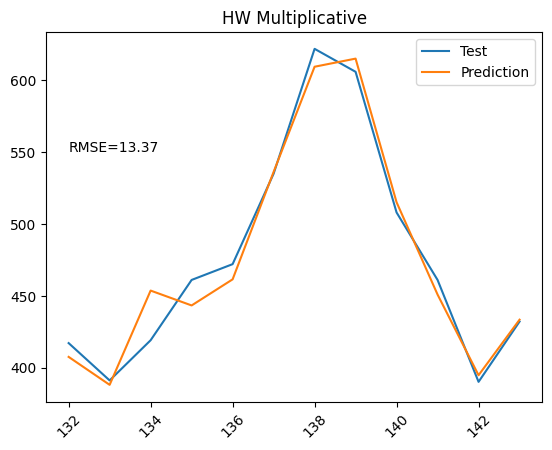

In [21]:
alpha = 0.103684
beta = 0.900000
gamma = 0.337895
hw_add = ExponentialSmoothing(y_train, seasonal_periods=12,  trend='add', seasonal='mul')
fit1 = hw_add.fit(smoothing_level=alpha, smoothing_trend=beta, smoothing_seasonal=gamma)
y_pred = fit1.forecast(len(y_test))
y_pred.index = y_test.index
plt.plot(y_test, label="Test")
plt.plot(y_pred, label="Prediction")
error = np.round(root_mean_squared_error(y_test, y_pred) ,2)
plt.text(132, 550, "RMSE="+str(error))
plt.title("HW Multiplicative")
plt.xticks(rotation=45)
plt.legend()
plt.show()